# Chạy từ dữ liệu thật đến submission

Đây là đường thực thi gọn sau khi đọc 00-07. `baseline` chạy LR 32 đặc trưng. `full` chạy đủ vòng sàng lọc, xác nhận shortlist qua ba seed, kiểm tra lỗi và blend với native, rồi khóa quyết định trước khi mở nhãn private. Cấu hình thắng do kết quả development quyết định, không được đặt sẵn là B2.

Cài môi trường theo README, giữ data ngoài repo và đặt `DATA_ROOT`, `TEST_ROOT` nếu không theo bố cục tự dò. `KMD_PROFILE=full` là mặc định; `KMD_INCLUDE_EXTENSIONS=1` bổ sung các phép thử phụ lục trước khi khóa. Chọn `KMD_SUBMISSION_STRATEGY=fold_ensemble` hoặc `refit_all` trước khi xem private. Dùng chung RUN_ID với chuỗi bài để tái sử dụng kết quả đã xác minh; dùng phiên mới khi giao thức hoặc code đã đổi.

In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kmd.core import read_csv, read_json, export_submission, write_json
from kmd.pipeline import prepare_development, start_session, load_pairs, complete_method_cv, aligned_predictions
from kmd.teaching import resolve_data_roots
from kmd.finalization import (MAIN_METHODS, EXTENSION_METHODS, freeze_review,
    predict_frozen_comparison, score_private, infer_method, refit_config, refit_all, infer_refit)

data_root, test_root = resolve_data_roots(TASK_ROOT)
RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
if os.environ.get('KMD_SMOKE', '0') == '1' or RUN_ID.endswith('_smoke'):
    raise ValueError('Bước chốt và nộp bài yêu cầu kết quả full, không dùng smoke.')
dev_frame = prepare_development(data_root)
session_dir = start_session(dev_frame, data_root, run_id=RUN_ID)
INCLUDE_EXTENSIONS = os.environ.get('KMD_INCLUDE_EXTENSIONS', '0') == '1'
STRATEGY = os.environ.get('KMD_SUBMISSION_STRATEGY', 'fold_ensemble')
if STRATEGY not in {'fold_ensemble', 'refit_all'}:
    raise ValueError('Chọn fold_ensemble hoặc refit_all trước khi xem private.')
print('Phiên:', session_dir, '| Chiến lược nộp:', STRATEGY)

Phiên: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh/artifacts/models/lesson_full_v5_20260920 | Chiến lược nộp: fold_ensemble


## 1. Từ sàng lọc đến quyết định

Full chạy sáu cấu hình sàng lọc tại seed 20260917: DenseNet center60@224 cap 48, DenseNet-288, center72@224, B0-224, B2-224 và B2-288. Baseline DenseNet cap 24 và native là các mốc bổ sung. Mỗi cấu hình có đủ ba fold trên cùng 800 cặp phát triển.

Hai challenger đứng đầu được xác nhận cùng `center60`, `center60_cap48`, `native` ở ba seed. Sau khi chọn mô hình đơn theo F1 trung bình, thử nó với native bằng trọng số50/50 cố định; chỉ giữ blend nếu mức tăng trung bình đạt0,50 điểm phần trăm. Native đứng đầu thì bỏ qua self-blend.

Các bài 05-06 giải thích cách đọc kết quả và những gì phép thử chưa chứng minh. Pipeline này gọi cùng API và không cần chạy lại những job có cache hợp lệ.

In [2]:
from kmd.pipeline import fit_lr_cv, train_frozen_lr_cv
from kmd.suite import (run_lr_suite, run_crop_comparison_suite,
    run_loss_comparison_suite, run_residual_suite, run_data_amount_suite)
from kmd.decision_flow import (run_backbone_screening_suite,
    run_single_confirmation_suite, run_selected_blend_suite)

PROFILE = os.environ.get('KMD_PROFILE', 'full')
if PROFILE not in {'baseline', 'full'}:
    raise ValueError('KMD_PROFILE phải là baseline hoặc full.')
if PROFILE == 'baseline' and INCLUDE_EXTENSIONS:
    raise ValueError('Các phụ lục cần KMD_PROFILE=full.')
fit_lr_cv(dev_frame, data_root, session_dir)
if PROFILE == 'baseline':
    selection = {'method': 'lr_full32', 'private_used': False, 'partition': 'development',
                 'rule': 'fixed baseline, no candidate selection', 'seed_for_submission': 20260917}
    methods = ['lr_full32']
else:
    for name in ('frozen', 'resampled'):
        complete_method_cv(name, dev_frame, data_root, session_dir, smoke=False)
    screening, screen_predictions = run_backbone_screening_suite(dev_frame, data_root, session_dir)
    confirmed, single_selection = run_single_confirmation_suite(dev_frame, data_root, session_dir)
    blend_table, selection = run_selected_blend_suite(dev_frame, data_root, session_dir)
    if selection is None:
        raise ValueError('Chưa có quyết định full hợp lệ.')
    selection = dict(selection)
    methods = list(selection['comparison_methods'])
    if INCLUDE_EXTENSIONS:
        run_lr_suite(dev_frame, data_root, session_dir)
        train_frozen_lr_cv('frozen_lr', dev_frame, data_root, session_dir, smoke=False)
        for suite in (run_crop_comparison_suite, run_loss_comparison_suite,
                      run_residual_suite, run_data_amount_suite):
            suite(dev_frame, data_root, session_dir, smoke=False)
        complete_method_cv('b2_resize', dev_frame, data_root, session_dir, smoke=False)
        methods = list(dict.fromkeys(methods + EXTENSION_METHODS))
selection['submission_strategy'] = STRATEGY
freeze_review(session_dir, methods, selection)
print('Đã khóa:', selection)

Đã khóa: {'protocol': 'backbone_flow_v1', 'method': 'b2', 'confirmed_methods': ['dense288', 'b2', 'center60', 'center60_cap48', 'native'], 'shortlist': ['dense288', 'b2'], 'seeds': [20260917, 20260918, 20260919], 'mean_macro_f1': {'dense288': 0.9683309593142767, 'b2': 0.9758330651008422, 'center60': 0.9666651534651262, 'center60_cap48': 0.9670822193355267, 'native': 0.96416417030004}, 'seed_for_submission': 20260917, 'partition': 'development', 'private_used': False, 'best_single': 'b2', 'blend_delta_vs_best_single': 0.004582512291988102, 'minimum_gain': 0.005, 'components': ['b2', 'native'], 'weights': [0.5, 0.5], 'comparison_methods': ['lr_full32', 'frozen', 'center60', 'center60_cap48', 'dense288', 'center72', 'b0_224', 'b2_224', 'b2', 'native', 'resampled', 'blend_selected_native'], 'blend_status': 'tested', 'submission_strategy': 'fold_ensemble'}


## 2. Đối chiếu private nếu có

Đặt `PRIVATE_ROOT`, `PRIVATE_LABELS`, `PRIVATE_LABEL_SOURCE` để tạo bảng. Đọc [bài 07](07_private_and_submission.ipynb) về khác biệt giữa OOF và ensemble test, nguồn nhãn và cách diễn giải. Thiếu nhãn thì bỏ qua chấm điểm, không đoán nhãn từ tên ảnh.

In [3]:
# PRIVATE_ROOT chứa pairs.csv không nhãn và ảnh; có thể khác TEST_ROOT dùng nộp.
private_raw = os.environ.get('PRIVATE_ROOT', '').strip()
private_dir = session_dir / 'private_fold_ensemble'
private_ready = False
if private_raw:
    private_root = Path(private_raw).expanduser().resolve()
    prediction_manifest = predict_frozen_comparison(session_dir, private_root, private_dir)
    private_ready = True
    print('Đã lưu toàn bộ dự đoán theo danh sách khóa:', private_dir)
else:
    print('Chưa cấu hình PRIVATE_ROOT: bỏ qua đối chiếu private, vẫn có thể xuất submission.')

Đã lưu toàn bộ dự đoán theo danh sách khóa: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh/artifacts/models/lesson_full_v5_20260920/private_fold_ensemble


               method  development_f1  private_f1  private_errors  private_n                       protocol
            lr_full32        0.788742    0.839936              16        100 3-fold ensemble, seed 20260917
               frozen        0.817499    0.869987              13        100 3-fold ensemble, seed 20260917
             center60        0.966246    0.959984               4        100 3-fold ensemble, seed 20260917
       center60_cap48        0.968748    0.980000               2        100 3-fold ensemble, seed 20260917
             dense288        0.973750    0.979992               2        100 3-fold ensemble, seed 20260917
             center72        0.954995    0.969997               3        100 3-fold ensemble, seed 20260917
               b0_224        0.961249    0.960000               4        100 3-fold ensemble, seed 20260917
               b2_224        0.965000    0.949995               5        100 3-fold ensemble, seed 20260917
                   b2       

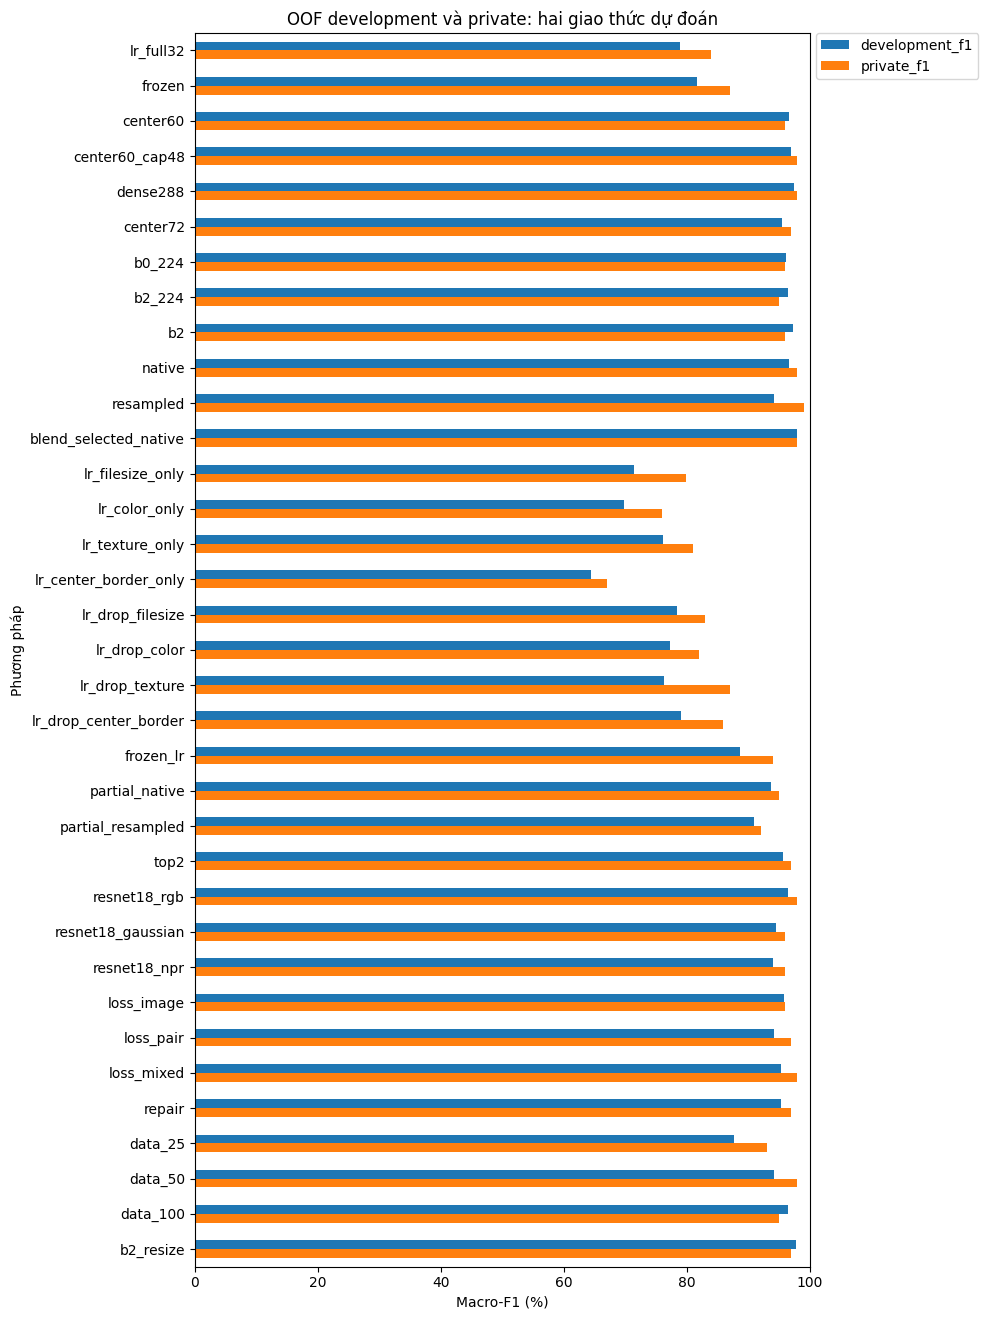

In [4]:
# Đây là bước duy nhất đọc nhãn private. Không dùng bảng này để chọn lại mô hình.
labels_raw = os.environ.get('PRIVATE_LABELS', '').strip()
label_source = os.environ.get('PRIVATE_LABEL_SOURCE', '').strip()
if private_ready and labels_raw and label_source:
    private_table = score_private(session_dir, private_dir, Path(labels_raw), label_source)
    print(private_table.to_string(index=False))
    ax = (private_table.set_index('method')[['development_f1', 'private_f1']] * 100).plot.barh(
        figsize=(10, max(5, len(methods) * .38)), xlim=(0, 100))
    ax.set(xlabel='Macro-F1 (%)', ylabel='Phương pháp', title='OOF development và private: hai giao thức dự đoán')
    ax.invert_yaxis()
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
    plt.tight_layout()
    plt.savefig(private_dir / 'development_private_comparison.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('Chưa chấm private. Cần đủ dự đoán, PRIVATE_LABELS và mô tả PRIVATE_LABEL_SOURCE.')

## 3. Xuất bài theo chiến lược đã chọn

Ensemble tái sử dụng ba checkpoint fold. Refit train mới trên 1.000 cặp với ngân sách chốt từ development, không chạy vòng chọn checkpoint bằng test. Xác suất và CSV được lưu riêng theo chiến lược. Nếu thiếu TEST_ROOT, cấu hình đường dẫn rồi chạy lại cell xuất bài.

In [5]:
if test_root is None:
    print('Chưa có TEST_ROOT: dừng ở kết quả development; cấu hình test rồi chạy lại cell này để xuất bài.')
else:
    test_frame = load_pairs(test_root, labeled=False)
    method = selection['method']
    if STRATEGY == 'refit_all':
        if method != 'lr_full32':
            for branch in (selection['components'] if method == 'blend_selected_native' else (method,)):
                cfg, fold_epochs = refit_config(branch, session_dir)
                print(branch, '| best epochs từng fold:', fold_epochs, '| ngân sách refit:', cfg.epochs)
        refit_all(method, data_root, session_dir)
        prediction = infer_refit(method, test_frame, test_root, session_dir)
    else:
        prediction = infer_method(method, test_frame, test_root, session_dir)
    prediction = aligned_predictions(prediction, test_frame)
    out_dir = session_dir / 'submission' / STRATEGY
    out_dir.mkdir(parents=True, exist_ok=True)
    prediction[['pair_id', 'p']].to_csv(out_dir / 'probabilities.csv', index=False)
    export_submission(prediction, out_dir / 'submission.csv')
    exported = read_csv(out_dir / 'submission.csv')
    assert exported.pair_id.tolist() == test_frame.pair_id.tolist()
    assert exported.pair_id.is_unique and exported.fake_position.isin([0, 1]).all()
    assert list(exported.columns) == ['pair_id', 'fake_position']
    print('Tệp nộp:', out_dir / 'submission.csv', '| số cặp:', len(exported))
    print(exported.head().to_string(index=False))

Tệp nộp: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh/artifacts/models/lesson_full_v5_20260920/submission/fold_ensemble/submission.csv | số cặp: 100
pair_id  fake_position
  00001              0
  00002              0
  00003              0
  00004              1
  00005              0


## 4. Các tệp cần đọc sau lượt chạy

Full lưu bảng sàng lọc, shortlist đã khóa, bảng xác nhận ba seed, lựa chọn mô hình đơn và quyết định sau thử blend. `review_freeze.json` nối quyết định đó với checkpoint và danh sách đối chiếu private. Bài nộp nằm ở `submission/<chiến lược>/submission.csv`.

Nếu chấm private, thư mục `private_fold_ensemble` có xác suất từng phương pháp, nguồn nhãn, bảng điểm và biểu đồ. Các biểu đồ giải thích chi tiết được tạo trong từng notebook bài học. Trước khi trình bày kết quả, kiểm tra job đã hoàn tất đủ ngân sách; kiểm tra cú pháp hoặc smoke không thay thế lượt chạy thật.